In [1]:
import numpy as np
import sklearn as sk
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [2]:
#Set the default figure size for the notebook, so they are not all tiny
matplotlib.rcParams['figure.figsize'] = (12,8)

In [3]:
#The data are spread across several csvs, my fault.
X_tr = pd.read_csv('x.014.tr.csv', index_col=0)
Y_tr = pd.read_csv('y.014.tr.csv', index_col=0)
X_te = pd.read_csv('x.014.te.csv', index_col=0)
Y_te = pd.read_csv('y.014.te.csv', index_col=0)

In [4]:
print(X_tr.shape)
print(Y_tr.shape)
print(X_te.shape)
print(Y_te.shape)

(2851, 256)
(2851, 1)
(823, 256)
(823, 1)


In [5]:
X_tr.head()

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,...,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257
1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000,-1.000,-1.000,-1.000,-0.996,...,-1.000,-1.000,-1.000,-0.109,1.000,-0.179,-1.0,-1.0,-1.0,-1.0
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000,-1.000,0.510,-0.213,-1.000,...,-0.654,0.666,0.301,-1.000,-1.000,-1.000,-1.0,-1.0,-1.0,-1.0
3,-1.0,-1.0,-1.0,-1.0,-1.0,-0.454,0.879,-0.745,-1.000,-1.000,...,1.000,1.000,1.000,0.506,-0.174,-0.811,-1.0,-1.0,-1.0,-1.0
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000,-1.000,-0.909,0.801,-0.899,...,-1.000,-0.332,0.735,0.380,-1.000,-1.000,-1.0,-1.0,-1.0,-1.0
5,-1.0,-1.0,-1.0,-1.0,-1.0,-0.877,0.233,1.000,0.996,0.116,...,-0.041,0.947,0.988,0.009,-0.931,-1.000,-1.0,-1.0,-1.0,-1.0


In [6]:
Y_tr.head()

,x
1,4
2,1
3,0
4,1
5,0


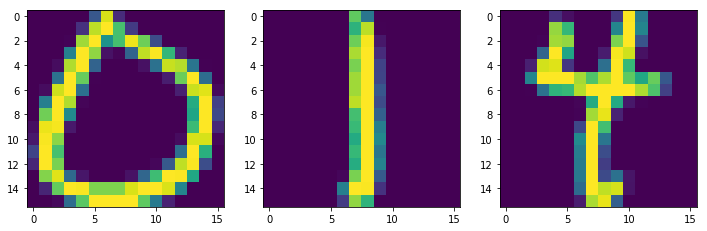

In [7]:
fig, axs = plt.subplots(1, 3)
demo_index = [2,1,7]
for i,ax in enumerate(axs):
    ax.imshow(X_tr.iloc[demo_index[i],:].values.reshape((16,16)))
plt.show()

Can we tell them apart?

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit(X_tr).transform(X_te)

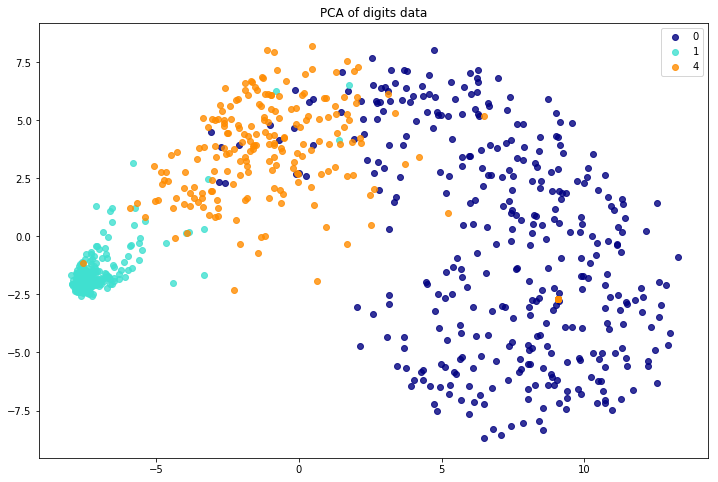

In [9]:
plt.figure()
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

#for color, i, target_name in zip(colors, [0, 1, 4], target_names):
for color, i in zip(colors, [0, 1, 4]):
    plt.scatter(X_pca[np.where(Y_te == i), 0], X_pca[np.where(Y_te == i), 1], color=color, alpha=.8,
                label=str(i))
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA of digits data')
plt.show()

In [10]:
lda = LinearDiscriminantAnalysis(n_components=2)
fit = lda.fit(X_tr, Y_tr.iloc[:,0])
yhat = fit.predict(X_te)

In [11]:
from sklearn.metrics import confusion_matrix

print(np.mean(Y_te.iloc[:,0] != yhat))

confusion_matrix(Y_te, yhat)



0.0206561360875


array([[353,   0,   6],
       [  1, 257,   6],
       [  0,   4, 196]])

In [12]:
X_lda = fit.transform(X_te)

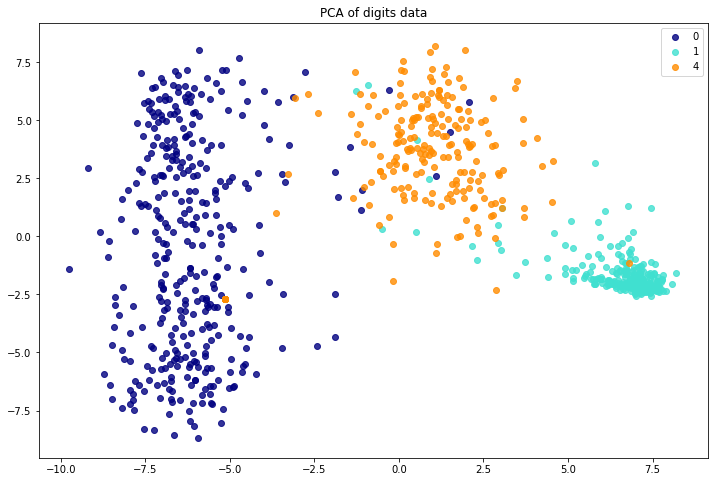

In [13]:
plt.figure()
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

#for color, i, target_name in zip(colors, [0, 1, 4], target_names):
for color, i in zip(colors, [0, 1, 4]):
    plt.scatter(X_lda[np.where(Y_te == i), 0], X_pca[np.where(Y_te == i), 1], color=color, alpha=.8,
                label=str(i))
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA of digits data')
plt.show()